# Rozpoznawanie na obrazu podstawie tęczówki - pipeline

## Część I: Wykrycie tęczówki na obrazie oka

In [133]:
%matplotlib inline
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pixel_transformations import binarize_avg

In [134]:
path = "/Users/lila/BiometriaProjekt1/BiometriaProjekt1/bryanl1.bmp"
img = Image.open(path).convert("RGB")
original_image = np.array(img)

gray = original_image[:, :, 0]

In [135]:
import matplotlib.pyplot as plt

def show_images(images, titles=None):
    n = len(images)
    # squeeze=False ensures 'axes' is always a 2D array, even if n=1
    fig, axes = plt.subplots(1, n, figsize=(n * 5, 5), squeeze=False)
    
    for i in range(n):
        axes[0, i].imshow(images[i])
        if titles: 
            axes[0, i].set_title(titles[i])
        axes[0, i].axis('off')
        
    plt.tight_layout()
    plt.show()


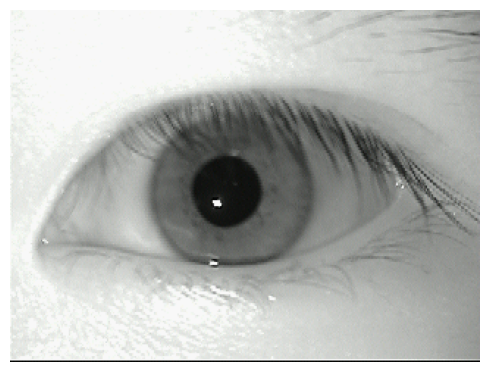

In [136]:
show_images([original_image])

Obliczenie średniej jasności obrazu

In [137]:
average_brightness = np.mean(original_image)
print(f"Średnia jasność obrazu: {average_brightness}")

Średnia jasność obrazu: 178.69557291666666


Binaryzacja dla źrenicy

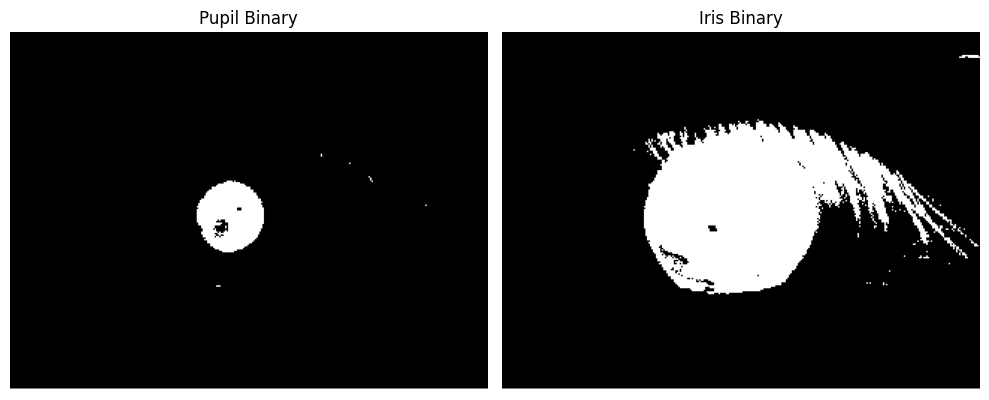

In [138]:
pupil_bin  = binarize_avg(original_image, x=6.2, invert=True)  # źrenica biała
iris_bin   = binarize_avg(original_image, x=1.5, invert=True)  # tęczówka biała
show_images([pupil_bin, iris_bin], titles=["Pupil Binary", "Iris Binary"])

**Zastosowanie operacji morfologiznych dla źrenicy:**
- otwarcie - pozbycie się pozostałych punktów
- zamknięcie - wypełnienie dziur

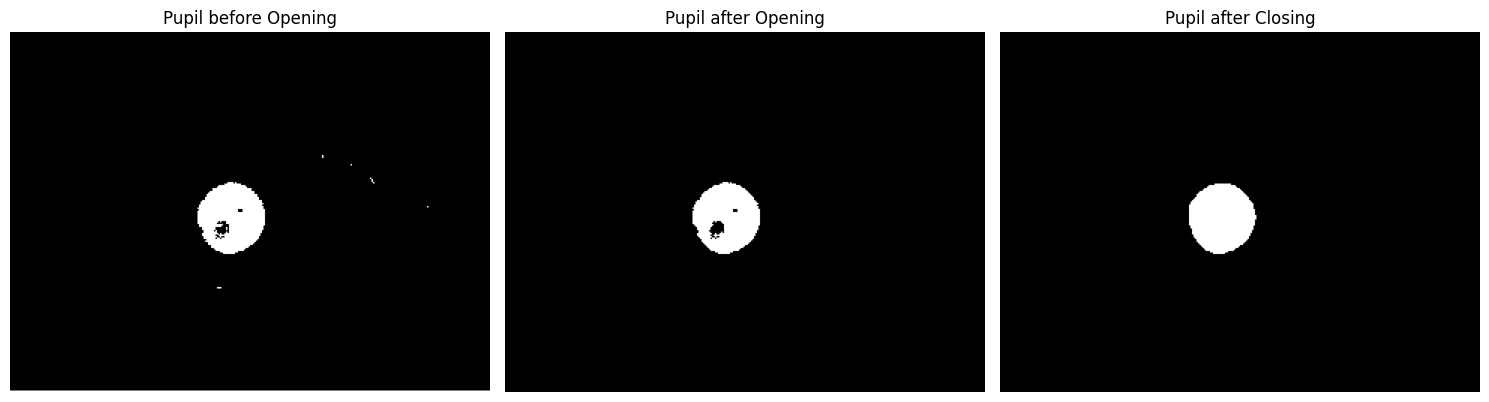

In [139]:
from morphological import opening, closing


pupil_opening = opening(pupil_bin, kernel_size=3, shape='circle')
pupil = closing(pupil_opening, kernel_size=20, shape='circle')
show_images([pupil_bin, pupil_opening, pupil], titles=["Pupil before Opening", "Pupil after Opening", "Pupil after Closing"])

Obliczenie środka źrenicy (zakładamy, że źrenica i tęczówka są współśrodkowe)

In [140]:
print(pupil.shape)

(240, 320, 3)


In [ ]:
def get_center(pupil):
    pupil_2d = pupil[:, :, 0]
    
    proj_vertical   = np.sum(pupil_2d, axis=0)
    proj_horizontal = np.sum(pupil_2d, axis=1)
    
    indices_x = np.arange(len(proj_vertical))
    indices_y = np.arange(len(proj_horizontal))
    cx = int(np.sum(indices_x * proj_vertical) / np.sum(proj_vertical))
    cy = int(np.sum(indices_y * proj_horizontal) / np.sum(proj_horizontal))
    
    
    print(f"Środek: ({cx}, {cy})")
    return (cx, cy)
cx, cy = get_center(pupil)

def get_radius(img_gray, cx, cy, r_min, r_max, num_angles=360, angle_mask=None):
    radii = np.arange(r_min, r_max)
    profile = np.zeros(len(radii))
    angles = np.linspace(0, 2 * np.pi, num_angles)
    
    if angle_mask is not None:
        angles = angles[angle_mask]
    
    for i, r in enumerate(radii):
        xs = np.clip((cx + r * np.cos(angles)).astype(int), 0, img_gray.shape[1] - 1)
        ys = np.clip((cy + r * np.sin(angles)).astype(int), 0, img_gray.shape[0] - 1)
        profile[i] = img_gray[ys, xs].mean()

    grad = np.abs(np.gradient(profile))
    return radii[np.argmax(grad)]

short_side = min(original_image.shape[:2])

angles_all = np.linspace(0, 2 * np.pi, 360)

# zatrzymujemy tylko kąty skierowane w lewo lub prawo, unikamy górnych/dolnych powiek
# 0° = prawo, 90° = dół, 180° = lewo, 270° = góra
# wykluczamy 60°–120° (dolna powieka) i 240°–300° (górna powieka)
# (uwaga! kąty dziwnie się zamieniają, bo 270 to góra)
eyelid_mask = ~(
    ((angles_all > np.radians(80))  & (angles_all < np.radians(100))) |
    ((angles_all > np.radians(210)) & (angles_all < np.radians(330)))
)

pupil_radius = get_radius(gray, cx, cy,
    r_min=int(0.05 * short_side),
    r_max=int(0.25 * short_side))  # nie potrzebujemy maski kątów dla źrenicy, bo nie sięga powiek

iris_radius = get_radius(gray, cx, cy,
    r_min=int(0.20 * short_side),
    r_max=int(0.55 * short_side),
    angle_mask=eyelid_mask)

print(f"Środek: ({cx}, {cy})")
print(f"Promień źrenicy: {pupil_radius}")
print(f"Promień tęczówki: {iris_radius}")

Środek: (147, 123)
Środek: (147, 123)
Promień źrenicy: 24
Promień tęczówki: 54


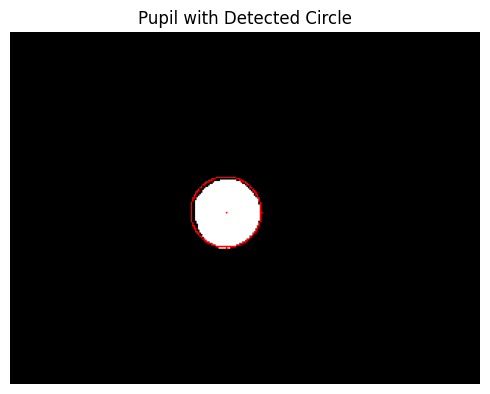

In [ ]:
def draw_img_with_circle(image, cx, cy, radius):
    img_with_circle = image.copy()
    img_with_circle[cy, cx] = [255, 0, 0] 
    for angle in range(0, 360, 1):
        x = int(cx + radius * np.cos(np.radians(angle)))
        y = int(cy + radius * np.sin(np.radians(angle)))
        if 0 <= x < img_with_circle.shape[1] and 0 <= y < img_with_circle.shape[0]:
            img_with_circle[y, x] = [255, 0, 0] 
    return img_with_circle
pupil_with_radius_and_center = draw_img_with_circle(pupil, cx, cy, pupil_radius)
show_images([pupil_with_radius_and_center], titles=["Pupil with Detected Circle"])

**Zastosowanie operacji morfologiznych dla tęczówki:**
- otwarcie - pozbycie się pozostałych rzęs
- zamknięcie - wypełnienie dziur


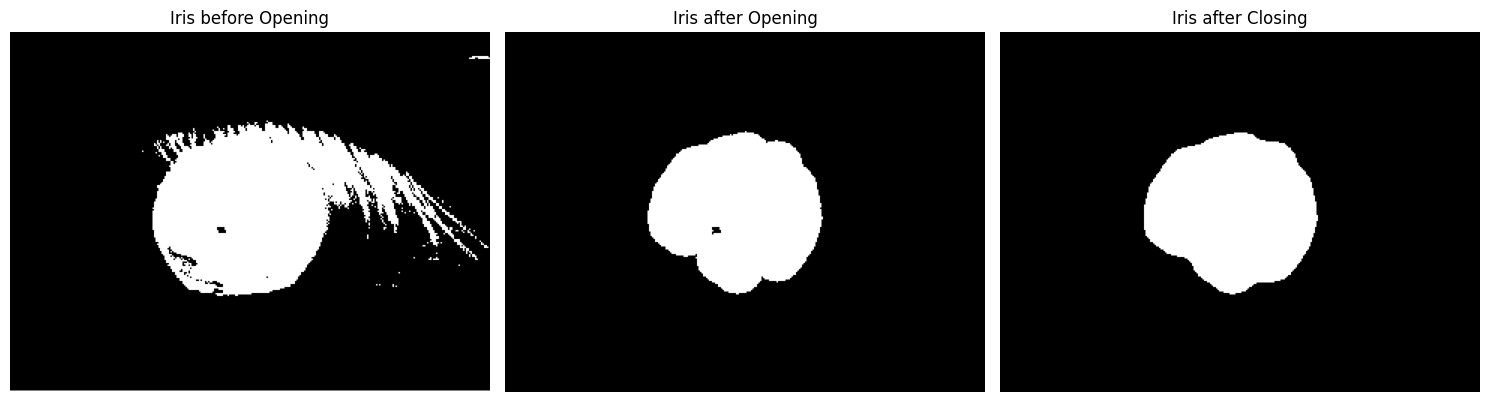

In [ ]:
from morphological import opening, closing


iris_bin_opening = opening(iris_bin, kernel_size=35, shape='circle')
iris = closing(iris_bin_opening, kernel_size=20, shape='circle')
show_images([iris_bin, iris_bin_opening, iris], titles=["Iris before Opening", "Iris after Opening", "Iris after Closing"])

Środek: (155, 118)


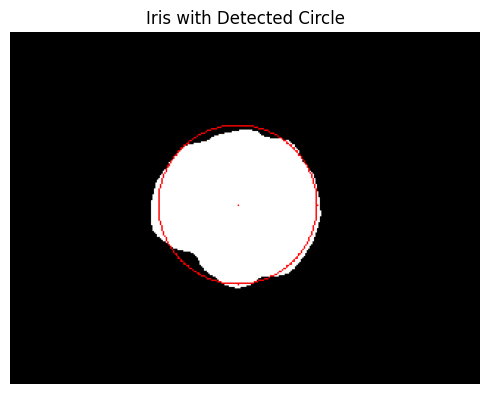

In [144]:
cx_iris, cy_iris = get_center(iris)
iris_with_radius_and_center = draw_img_with_circle(iris, cx_iris, cy_iris, iris_radius)
show_images([iris_with_radius_and_center], titles=["Iris with Detected Circle"])

In [ ]:
def apply_iris_mask(img, iris_mask_2d, pupil_mask_2d):
    ring_mask = np.where(iris_mask_2d == 255, 1, 0) - \
                np.where(pupil_mask_2d == 255, 1, 0)
    ring_mask = np.clip(ring_mask, 0, 1)
    
    ring_mask_3d = np.stack([ring_mask, ring_mask, ring_mask], axis=-1)
    result = (img * ring_mask_3d).astype(np.uint8)
    
    return result

In [146]:
iris_region = apply_iris_mask(original_image, iris[:, :, 0], pupil[:, :, 0])
outside_region = apply_iris_mask(original_image, 255 - iris[:, :, 0], pupil[:, :, 0])
eye_with_radius_and_center = draw_img_with_circle(original_image, cx, cy, pupil_radius)
eye_with_radius_and_center = draw_img_with_circle(eye_with_radius_and_center, cx, cy, iris_radius)


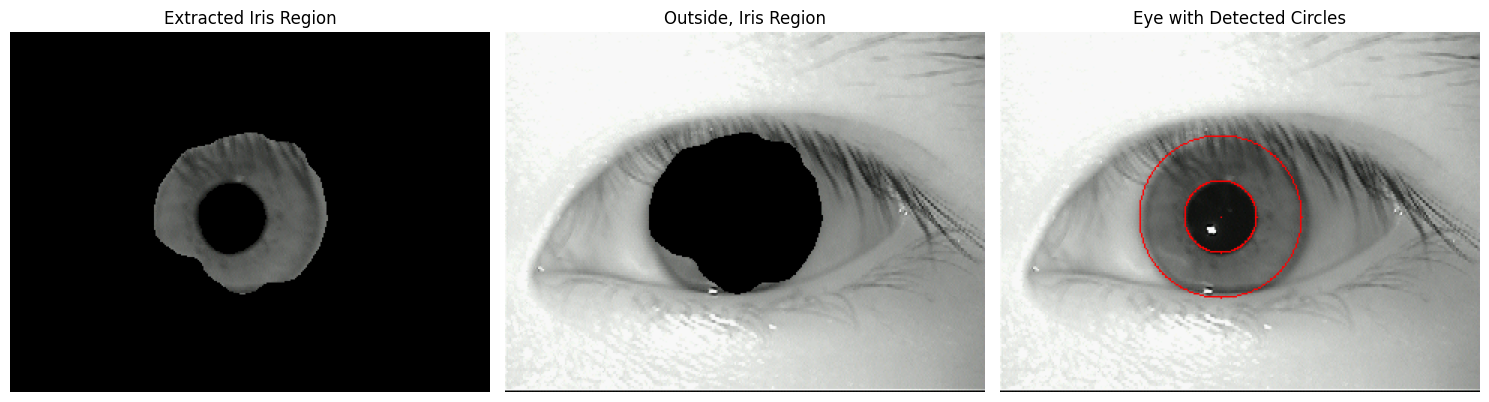

In [147]:
show_images([iris_region, outside_region, eye_with_radius_and_center], titles=["Extracted Iris Region", "Outside, Iris Region", "Eye with Detected Circles"])

## Część II: Uzyskanie kodu tęczówki - Algorytm Daugmana

### Transformacja do prostokąta

In [148]:
def unwrap_iris(img, cx, cy, r_inner, r_outer, num_angles=360, num_radii=64):
    """
    cx, cy      - środek źrenicy
    r_inner     - promień źrenicy
    r_outer     - promień tęczówki
    num_angles  - szerokość prostokąta (kolumny)
    num_radii   - wysokość prostokąta (wiersze = pasy radialne)
    """
    h, w = img.shape[:2]
    result = np.zeros((num_radii, num_angles, 3), dtype=np.uint8)
    
    angles = np.linspace(0, 2 * np.pi, num_angles)
    radii  = np.linspace(r_inner, r_outer, num_radii)
    
    for i, r in enumerate(radii):
        for j, theta in enumerate(angles):
            # biegunowe → kartezjańskie
            x = int(cx + r * np.cos(theta))
            y = int(cy + r * np.sin(theta))
            
            # sprawdź czy piksel jest w obrazie
            if 0 <= x < w and 0 <= y < h:
                result[i, j] = img[y, x]
    
    return result

unwrapped = unwrap_iris(original_image, cx, cy, pupil_radius, iris_radius)

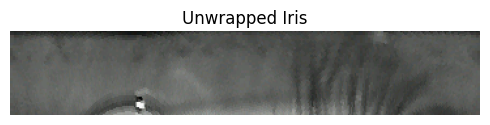

In [149]:
show_images([unwrapped], titles=["Unwrapped Iris"])

### Podział na 8 pasów radialnych

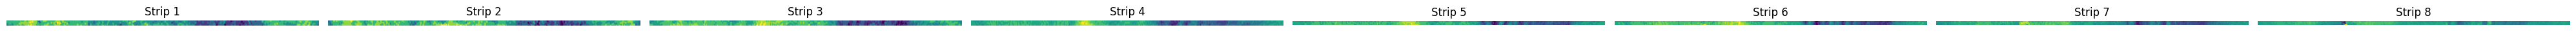

In [150]:
strips = np.array_split(unwrapped[10:54, :, 0], 8, axis=0)  # 8 pasów
show_images([strip for strip in strips], titles=[f"Strip {i+1}" for i in range(8)])

### Transformata Gabora

In [ ]:
def gabor_encode(strip, f=0.1):
    sigma = 0.5 * np.pi * f
    avg = strip.mean(axis=0)         
    
    kernel_size = 32
    x = np.arange(kernel_size) - kernel_size // 2  
    kernel_real = np.cos(2 * np.pi * f * x) * np.exp(-x**2 / (2 * sigma**2))
    kernel_imag = np.sin(2 * np.pi * f * x) * np.exp(-x**2 / (2 * sigma**2))
    
    resp_real = np.convolve(avg, kernel_real, mode='same')
    resp_imag = np.convolve(avg, kernel_imag, mode='same')
    
    bits_real = (resp_real > 0).astype(int)
    bits_imag = (resp_imag > 0).astype(int)
    
    return np.concatenate([bits_real, bits_imag])

def get_iris_code(strips, freqs=(0.05, 0.1, 0.2, 0.4)):
    return np.concatenate([gabor_encode(s, f) for s in strips for f in freqs])

In [152]:
code = get_iris_code(strips)
print(f"Iris code (length {len(code)}):")
print(code)

Iris code (length 23040):
[1 1 1 ... 1 1 0]


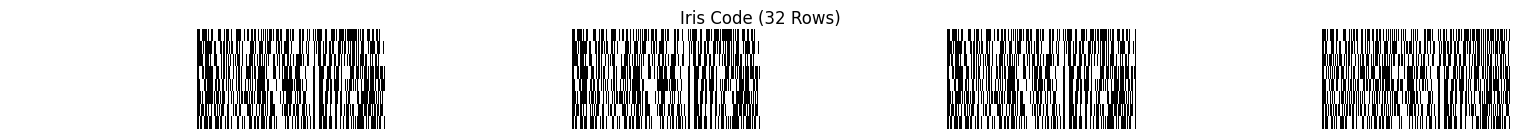

In [153]:
import matplotlib.pyplot as plt

code_2d = code.reshape(8, -1)
fig, ax = plt.subplots(figsize=(15, 1))
ax.imshow(code_2d, cmap='gray', aspect='auto', interpolation='nearest')
ax.set_axis_off()
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.text(0.5, 1.05, 'Iris Code (32 Rows)', transform=ax.transAxes, 
         ha='center', fontsize=12)

plt.show()

### Obliczenie odległośći:
Spodziewamy się:
- małej odległości pomiędzy kodami tęczówek utworzonych na podstawie tego samego oka tej samej osoby
- dużych odległości pomiędzy osobami, oraz pomiędzy obrazami prawego i lewego oka tej samej osoby

In [154]:
def hamming(code1, code2):
    return np.sum(code1 != code2) / len(code1)

In [155]:
def hamming_with_shift(code1, code2, max_shift=80):
    """Try shifting code2 left and right, return minimum distance."""
    best = 1.0
    n = len(code1)
    for shift in range(-max_shift, max_shift + 1):
        shifted = np.roll(code2, shift)
        d = np.sum(code1 != shifted) / n
        if d < best:
            best = d
    return best

[aeval1] Processing...
[aevar1] Processing...
[bryanl2] Processing...
[aeval2] Processing...
Hamming distance between two images of the same eye: 0.19544270833333333
Hamming distance between left and right eye (same person): 0.24487847222222223
Hamming distance between two people: 0.24110243055555555


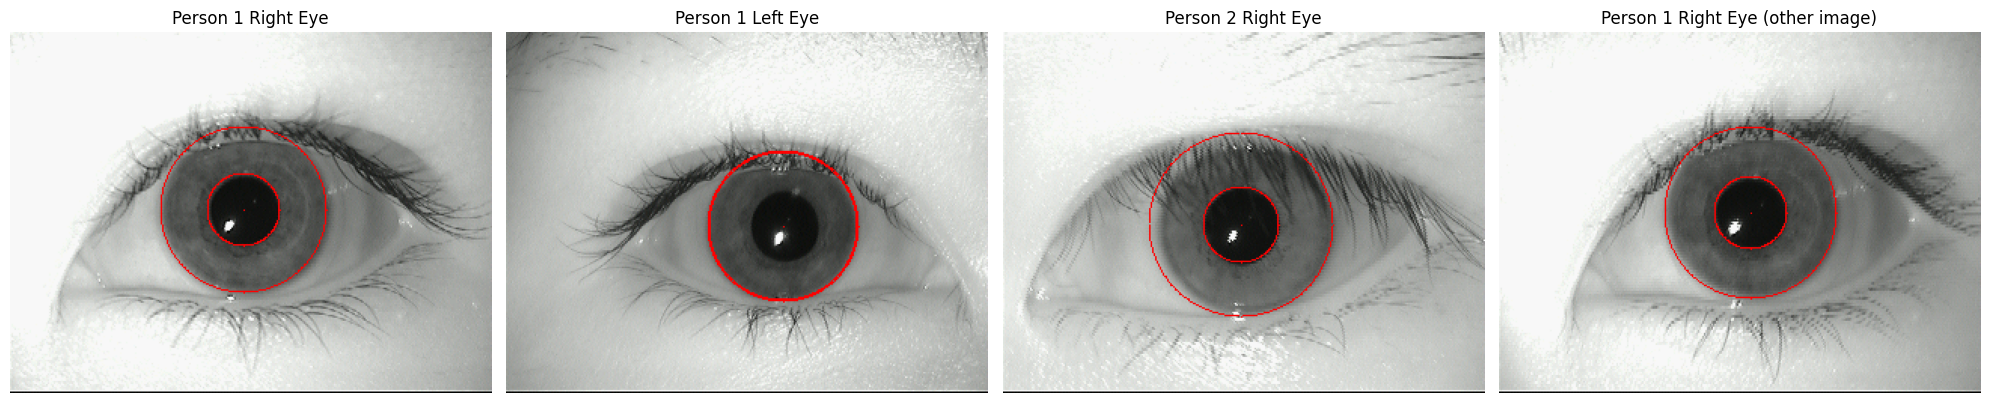

In [156]:
from iris_detection import process_image

res_1_right = process_image('/Users/lila/Downloads/Flattened/aeval1.bmp')
res_1_left = process_image('/Users/lila/Downloads/Flattened/aevar1.bmp')
res_2_right = process_image('/Users/lila/Downloads/Flattened/bryanl2.bmp')
res_1_right_other = process_image('/Users/lila/Downloads/Flattened/aeval2.bmp')

code_1_right = res_1_right["code"]
code_1_left = res_1_left["code"]
code_2_right = res_2_right["code"]
code_1_right_other = res_1_right_other["code"]

overlay_1_right = res_1_right["overlay"]
overlay_1_left = res_1_left["overlay"]
overlay_2_right = res_2_right["overlay"]
overlay_1_right_other = res_1_right_other["overlay"]

print("Hamming distance between two images of the same eye:", hamming_with_shift(code_1_right, code_1_right_other))
print("Hamming distance between left and right eye (same person):", hamming_with_shift(code_1_right, code_1_left))
print("Hamming distance between two people:", hamming_with_shift(code_1_right, code_2_right))

show_images([overlay_1_right, overlay_1_left, overlay_2_right, overlay_1_right_other],
            titles=["Person 1 Right Eye", "Person 1 Left Eye", "Person 2 Right Eye", "Person 1 Right Eye (other image)"])

In [157]:
import os
import glob
from itertools import combinations

def get_codes_for_dataset(base_path, n=5):
    """Returns dict: {(person_id, eye): [code1, code2, ...]}"""
    codes = {}
    
    all_persons = sorted(os.listdir(base_path))
    selected_persons = all_persons[:n]  # take first n

    for person_dir in selected_persons:
        # rest of the loop unchanged
        person_path = os.path.join(base_path, person_dir)
        if not os.path.isdir(person_path):
            continue
            
        for eye in ['left', 'right']:
            eye_path = os.path.join(person_path, eye)
            if not os.path.isdir(eye_path):
                continue
                
            images = glob.glob(os.path.join(eye_path, '*.bmp'))
            eye_codes = []
            
            for img_path in sorted(images):
                try:
                    result = process_image(img_path)
                    eye_codes.append(result["code"])
                    print(f"OK: {img_path}")
                except Exception as e:
                    print(f"FAIL: {img_path}: {e}")
            
            if eye_codes:
                codes[(person_dir, eye)] = eye_codes
    
    return codes

base_path = '/Users/lila/Downloads/MMU-Iris-Database'
codes = get_codes_for_dataset(base_path)

[aeval1] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/left/aeval1.bmp
[aeval2] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/left/aeval2.bmp
[aeval3] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/left/aeval3.bmp
[aeval4] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/left/aeval4.bmp
[aeval5] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/left/aeval5.bmp
[aevar1] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/right/aevar1.bmp
[aevar2] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/right/aevar2.bmp
[aevar3] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/right/aevar3.bmp
[aevar4] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/right/aevar4.bmp
[aevar5] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/right/aevar5.bmp
[fional1] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/10/left/fional1.bmp
[fional2] Processing...
OK: /Users/lila/Downloads/MMU-Iri

Saved to distance_matrix.png


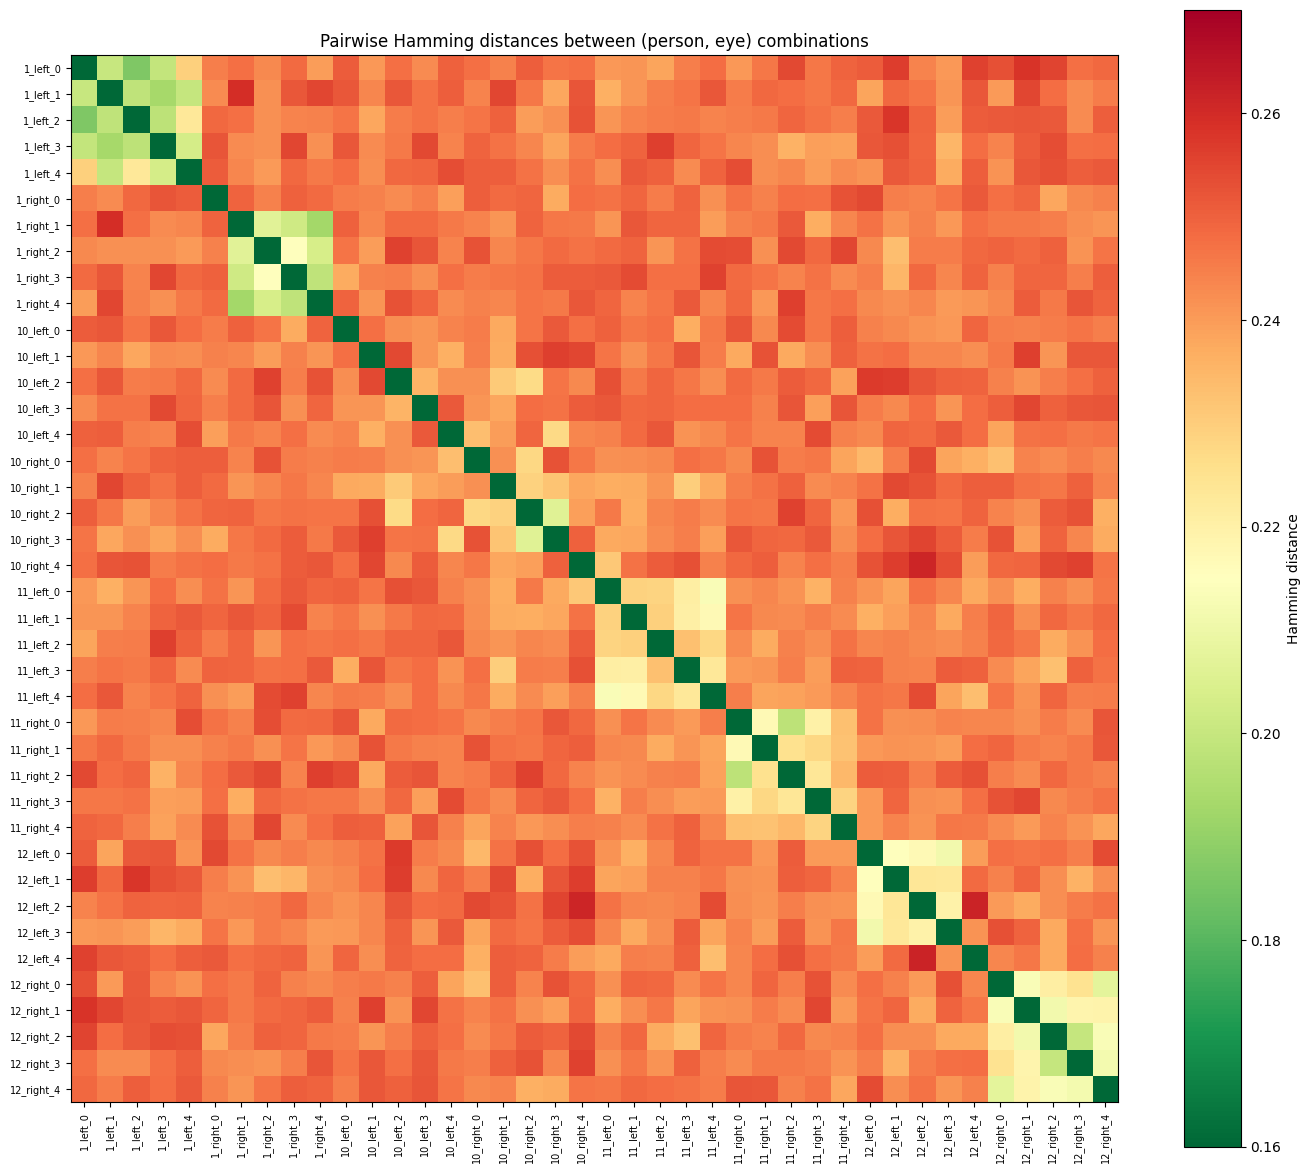

In [158]:
import matplotlib.pyplot as plt
import numpy as np

# build a list of (label, code) using first image from each key
labels = []
all_codes = []

for (person, eye), eye_codes in codes.items():
    for idx, code in enumerate(eye_codes):
        labels.append(f"{person}_{eye}_{idx}")
        all_codes.append(code)

n = len(all_codes)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = hamming(all_codes[i], all_codes[j])

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(dist_matrix, cmap='RdYlGn_r', vmin=0.16, vmax=0.27)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, fontsize=7, rotation=90)
ax.set_yticklabels(labels, fontsize=7)

plt.colorbar(im, ax=ax, label='Hamming distance')
ax.set_title('Pairwise Hamming distances between (person, eye) combinations')
plt.tight_layout()
plt.savefig('distance_matrix.png', dpi=150, bbox_inches='tight')
print("Saved to distance_matrix.png")

### Porównanie odległości dla całego datasetu:

In [159]:
codes = get_codes_for_dataset(base_path, n=46)

[aeval1] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/left/aeval1.bmp
[aeval2] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/left/aeval2.bmp
[aeval3] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/left/aeval3.bmp
[aeval4] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/left/aeval4.bmp
[aeval5] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/left/aeval5.bmp
[aevar1] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/right/aevar1.bmp
[aevar2] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/right/aevar2.bmp
[aevar3] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/right/aevar3.bmp
[aevar4] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/right/aevar4.bmp
[aevar5] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/1/right/aevar5.bmp
[fional1] Processing...
OK: /Users/lila/Downloads/MMU-Iris-Database/10/left/fional1.bmp
[fional2] Processing...
OK: /Users/lila/Downloads/MMU-Iri

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# build a list of (label, code) using first image from each key
labels = []
all_codes = []

for (person, eye), eye_codes in codes.items():
    for idx, code in enumerate(eye_codes):
        labels.append(f"{person}_{eye}_{idx}")
        all_codes.append(code)

n = len(all_codes)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = hamming(all_codes[i], all_codes[j])

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ph/0p7p4bp55m7844fgjb81w5s00000gn/T/ipykernel_33930/3264135781.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.text(mu_same, plt.ylim()[1] * 0.75, f"$\mu = {mu_same:.3f}$\n$\sigma = {std_same:.3f}$", ha='center', fontsize=12)
/var/folders/ph/0p7p4bp55m7844fgjb81w5s00000gn/T/ipykernel_33930/3264135781.py:21: SyntaxWarning: invalid escape sequence '\s'
  plt.text(mu_same, plt.ylim()[1] * 0.75, f"$\mu = {mu_same:.3f}$\n$\sigma = {std_same:.3f}$", ha='center', fontsize=12)
/var/folders/ph/0p7p4bp55m7844fgjb81w5s00000gn/T/ipykernel_33930/3264135781.py:22: SyntaxWarning

Saved to histogram.png


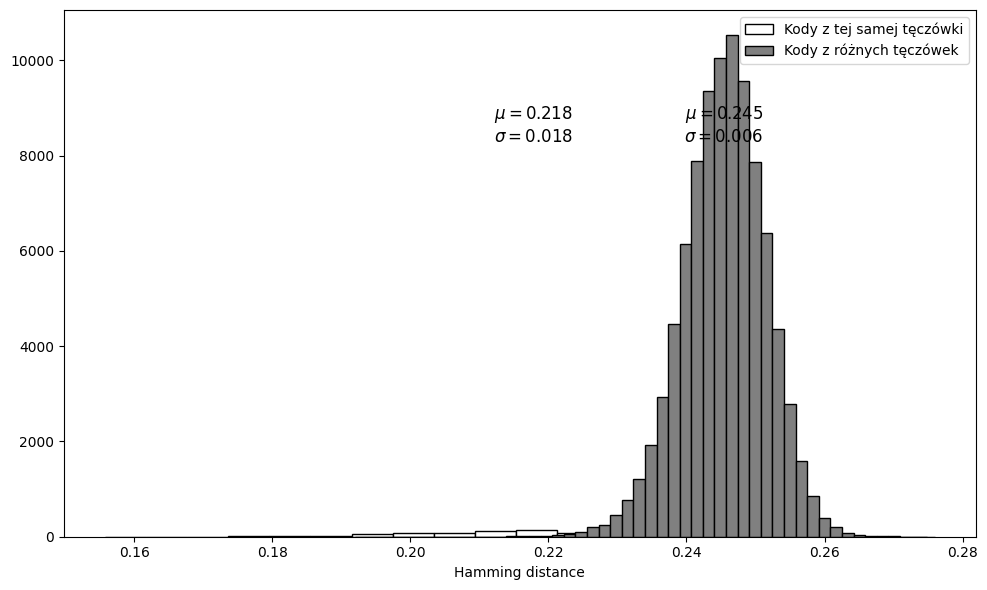

In [161]:
same_eye = []
diff_eye = []

for i in range(n):
    for j in range(i + 1, n):
        # Odcięcie końcówki '_{idx}' z etykiety 'osoba_oko_idx'
        if labels[i].rsplit('_', 1)[0] == labels[j].rsplit('_', 1)[0]:
            same_eye.append(dist_matrix[i, j])
        else:
            diff_eye.append(dist_matrix[i, j])

plt.figure(figsize=(10, 6))

plt.hist(same_eye, bins=20, color='white', edgecolor='black', label='Kody z tej samej tęczówki')
plt.hist(diff_eye, bins=50, color='gray', edgecolor='black', label='Kody z różnych tęczówek')

mu_same, std_same = np.mean(same_eye), np.std(same_eye)
mu_diff, std_diff = np.mean(diff_eye), np.std(diff_eye)

# Dodanie statystyk na wykresie
plt.text(mu_same, plt.ylim()[1] * 0.75, f"$\mu = {mu_same:.3f}$\n$\sigma = {std_same:.3f}$", ha='center', fontsize=12)
plt.text(mu_diff, plt.ylim()[1] * 0.75, f"$\mu = {mu_diff:.3f}$\n$\sigma = {std_diff:.3f}$", ha='center', fontsize=12)

plt.xlabel('Hamming distance')
plt.legend(loc='upper right')
plt.tight_layout()

plt.savefig('histogram.png', dpi=150, bbox_inches='tight')
print("Saved to histogram.png")